In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier 
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay





In [2]:
# read the data
data=pd.read_csv('../data/raw/student-por.csv')
data.shape

(649, 33)

In [3]:
# let see top 5 record
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
# see our data columns
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [5]:
# info about our data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [6]:
# let see our data statistical information
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [7]:
# let us select feature we want for our model
features = [
    'school',
    'sex',
    'age',
    'address',
    'famsize',
    'Pstatus',
    'Medu',
    'Fedu',
    'Mjob',
    'Fjob',
    'reason',
    'guardian',
    'traveltime',
    'studytime',
    'failures',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'nursery',
    'higher',
    'internet',
    'romantic',
    'famrel',
    'freetime',
    'goout',
    'Dalc',
    'Walc',
    'health',
    'absences'
]



In [8]:
# create our target column
data['At_Risk'] = (data['G3'] < 10).astype(int)

In [9]:
# let see our data who needs support or not
   # 1 → Requires additional support
   # 0 → Does not require additional support
print(data['At_Risk'].value_counts())

At_Risk
0    549
1    100
Name: count, dtype: int64


In [10]:
# let us devide our data into target and feature
X = data[features]
y = data['At_Risk']

In [11]:
# 1. Separate 15% for final testing
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 2. From the remaining 85%, take 15% of the ORIGINAL data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=15/85,
    random_state=42,
    stratify=y_temp
)
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
At_Risk
0    0.845475
1    0.154525
Name: proportion, dtype: float64

Validation:
At_Risk
0    0.846939
1    0.153061
Name: proportion, dtype: float64

Test:
At_Risk
0    0.846939
1    0.153061
Name: proportion, dtype: float64


In [12]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (453, 30)
Validation: (98, 30)
Test: (98, 30)


In [13]:

numerical_features = [
    'age',
    'Medu',
    'Fedu',
    'traveltime',
    'studytime',
    'failures',
    'famrel',
    'freetime',
    'goout',
    'Dalc',
    'Walc',
    'health',
    'absences'
]

categorical_features = [
    'school',
    'sex',
    'address',
    'famsize',
    'Pstatus',
    'Mjob',
    'Fjob',
    'reason',
    'guardian',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'nursery',
    'higher',
    'internet',
    'romantic'
]

preprocessor = ColumnTransformer(
    transformers=[
       ('num', StandardScaler(), numerical_features),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [14]:
# models we gonna train on 
models = {
    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),

    "LightGBM": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            random_state=42,
            verbose=-1
        ))
    ])
}

In [15]:
# train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

Logistic Regression trained successfully
Random Forest trained successfully
LightGBM trained successfully


In [16]:
# let us evaluate our models
for name, model in models.items():
    y_val_pred = model.predict(X_val)

    print(f"\n{name}")
    print(classification_report(y_val, y_val_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        83
           1       0.57      0.27      0.36        15

    accuracy                           0.86        98
   macro avg       0.73      0.62      0.64        98
weighted avg       0.83      0.86      0.83        98


Random Forest
              precision    recall  f1-score   support

           0       0.86      0.99      0.92        83
           1       0.67      0.13      0.22        15

    accuracy                           0.86        98
   macro avg       0.76      0.56      0.57        98
weighted avg       0.83      0.86      0.81        98


LightGBM
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        83
           1       0.67      0.27      0.38        15

    accuracy                           0.87        98
   macro avg       0.77      0.62      0.65        98
weighted avg       0.85     

In [17]:


results = []

for name, model in models.items():

    y_val_pred = model.predict(X_val)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred),
        'Recall': recall_score(y_val, y_val_pred),
        'F1': f1_score(y_val, y_val_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.857143   0.571429  0.266667  0.363636
1        Random Forest  0.857143   0.666667  0.133333  0.222222
2             LightGBM  0.867347   0.666667  0.266667  0.380952


In [18]:


for name, model in models.items():

    y_val_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_val_pred)

    print(f"\n{name}")
    print(cm)


Logistic Regression
[[80  3]
 [11  4]]

Random Forest
[[82  1]
 [13  2]]

LightGBM
[[81  2]
 [11  4]]


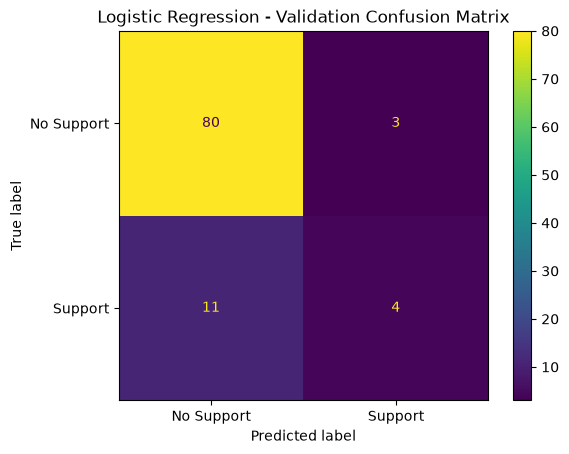

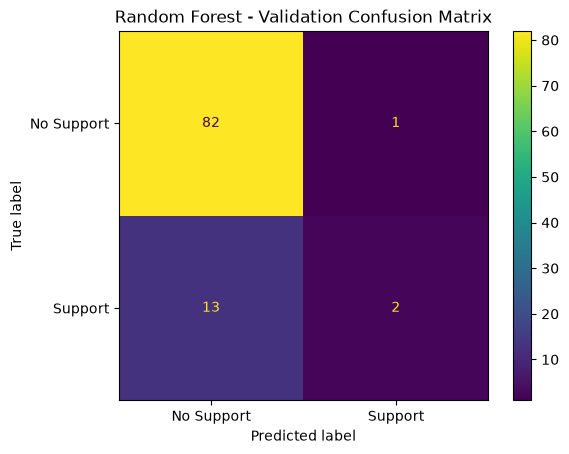

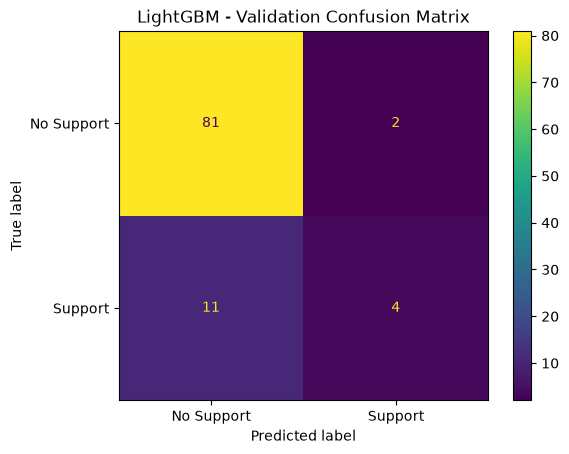

In [19]:

for name, model in models.items():

    y_val_pred = model.predict(X_val)

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_val_pred,
        display_labels=['No Support', 'Support']
    )

    plt.title(f'{name} - Validation Confusion Matrix')
    plt.show()

In [20]:
# from sklearn.metrics import precision_score, recall_score, f1_score

# model = models["Logistic Regression"]

# y_val_proba = model.predict_proba(X_val)[:, 1]

# thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20,0.21,0.22,0.24]

# for threshold in thresholds:

#     y_pred = (y_val_proba >= threshold).astype(int)

#     precision = precision_score(y_val, y_pred, zero_division=0)
#     recall = recall_score(y_val, y_pred, zero_division=0)
#     f1 = f1_score(y_val, y_pred, zero_division=0)

#     print(
#         f"Threshold: {threshold:.2f} | "
#         f"Precision: {precision:.3f} | "
#         f"Recall: {recall:.3f} | "
#         f"F1: {f1:.3f}"
#     )

In [21]:
# thresholds = [
#     0.50, 0.45, 0.40, 0.35,0.21,
#     0.30, 0.25, 0.20, 0.15, 0.10
# ]

# for name, model in models.items():

#     print(f"\n{'='*50}")
#     print(name)
#     print(f"{'='*50}")

#     y_val_proba = model.predict_proba(X_val)[:, 1]

#     for threshold in thresholds:

#         y_pred = (y_val_proba >= threshold).astype(int)

#         precision = precision_score(
#             y_val, y_pred, zero_division=0
#         )

#         recall = recall_score(
#             y_val, y_pred, zero_division=0
#         )

#         f1 = f1_score(
#             y_val, y_pred, zero_division=0
#         )

#         print(
#             f"Threshold: {threshold:.2f} | "
#             f"Precision: {precision:.3f} | "
#             f"Recall: {recall:.3f} | "
#             f"F1: {f1:.3f}"
#         )

In [22]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.51, 0.01)

best_results = []

for name, model in models.items():

    y_val_proba = model.predict_proba(X_val)[:, 1]

    best_threshold = None
    best_f1 = 0
    best_precision = 0
    best_recall = 0

    for threshold in thresholds:

        y_pred = (y_val_proba >= threshold).astype(int)

        precision = precision_score(
            y_val, y_pred, zero_division=0
        )

        recall = recall_score(
            y_val, y_pred, zero_division=0
        )

        f1 = f1_score(
            y_val, y_pred, zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall

    best_results.append({
        'Model': name,
        'Best Threshold': best_threshold,
        'Precision': best_precision,
        'Recall': best_recall,
        'F1': best_f1
    })

best_results_df = pd.DataFrame(best_results)

print(best_results_df)

                 Model  Best Threshold  Precision    Recall        F1
0  Logistic Regression            0.21   0.565217  0.866667  0.684211
1        Random Forest            0.23   0.526316  0.666667  0.588235
2             LightGBM            0.11   0.529412  0.600000  0.562500


In [28]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a fresh pipeline for tuning
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

# Hyperparameters to test
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

# Stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Tune based on F1
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

# IMPORTANT: only training data
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informat

In [29]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'classifier__C': 0.01}

Best CV F1:
0.4745603793756089


In [30]:
best_log_reg = grid_search.best_estimator_
y_val_proba = best_log_reg.predict_proba(X_val)[:, 1]

In [31]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:

    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df.sort_values(
        'F1',
        ascending=False
    ).head(10)
)

    Threshold  Precision    Recall        F1
40       0.50   0.545455  0.800000  0.648649
38       0.48   0.481481  0.866667  0.619048
34       0.44   0.441176  1.000000  0.612245
35       0.45   0.451613  0.933333  0.608696
37       0.47   0.451613  0.933333  0.608696
36       0.46   0.451613  0.933333  0.608696
39       0.49   0.480000  0.800000  0.600000
33       0.43   0.416667  1.000000  0.588235
32       0.42   0.357143  1.000000  0.526316
31       0.41   0.348837  1.000000  0.517241


In [32]:
final_model = models["Logistic Regression"]
final_threshold = 0.21

In [34]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= final_threshold).astype(int)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Accuracy: 0.8061224489795918
Precision: 0.375
Recall: 0.4
F1: 0.3870967741935484

Confusion Matrix:
[[73 10]
 [ 9  6]]
